<a href="https://colab.research.google.com/github/NidhiDekate/BigMart-Sales-Prediction/blob/main/Big_Mart_Sales_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#import dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#import functions
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
project_folder = '/content/drive/MyDrive/BigMart_Sales_Prediction'
os.makedirs(project_folder, exist_ok=True)
print(f"Project folder ready at: {project_folder}")

Project folder ready at: /content/drive/MyDrive/BigMart_Sales_Prediction


In [4]:
import json, os

os.makedirs('/root/.kaggle', exist_ok=True)

kaggle_creds = {
    "username": "nidhi dekate",
    "key": "KGAT_3977d04b7bc32383d85e662521be3674"
}

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)

os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("Done!")

Done!


In [5]:
!kaggle datasets download -d brijbhushannanda1979/bigmart-sales-data \
    -p '/content/drive/MyDrive/BigMart_Sales_Prediction'

!unzip '/content/drive/MyDrive/BigMart_Sales_Prediction/bigmart-sales-data.zip' \
    -d '/content/drive/MyDrive/BigMart_Sales_Prediction/'

Dataset URL: https://www.kaggle.com/datasets/brijbhushannanda1979/bigmart-sales-data
License(s): CC0-1.0
bigmart-sales-data.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  /content/drive/MyDrive/BigMart_Sales_Prediction/bigmart-sales-data.zip
replace /content/drive/MyDrive/BigMart_Sales_Prediction/Test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: /content/drive/MyDrive/BigMart_Sales_Prediction/Test.csv  
  inflating: /content/drive/MyDrive/BigMart_Sales_Prediction/Train.csv  


In [6]:
import os
print(os.listdir('/content/drive/MyDrive/BigMart_Sales_Prediction/'))

['bigmart-sales-data.zip', 'Test.csv', 'Train.csv']


data collection & analysis

In [7]:
big_mart_data = pd.read_csv('/content/drive/MyDrive/BigMart_Sales_Prediction/Train.csv')
test = pd.read_csv('/content/drive/MyDrive/BigMart_Sales_Prediction/Test.csv')

print(big_mart_data.shape, test.shape)
print(big_mart_data.head())

(8523, 12) (5681, 11)
  Item_Identifier  Item_Weight Item_Fat_Content  Item_Visibility  \
0           FDA15         9.30          Low Fat         0.016047   
1           DRC01         5.92          Regular         0.019278   
2           FDN15        17.50          Low Fat         0.016760   
3           FDX07        19.20          Regular         0.000000   
4           NCD19         8.93          Low Fat         0.000000   

               Item_Type  Item_MRP Outlet_Identifier  \
0                  Dairy  249.8092            OUT049   
1            Soft Drinks   48.2692            OUT018   
2                   Meat  141.6180            OUT049   
3  Fruits and Vegetables  182.0950            OUT010   
4              Household   53.8614            OUT013   

   Outlet_Establishment_Year Outlet_Size Outlet_Location_Type  \
0                       1999      Medium               Tier 1   
1                       2009      Medium               Tier 3   
2                       1999      Med

In [8]:
big_mart_data.shape #no. of datapoints and features

(8523, 12)

In [9]:
big_mart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [10]:
big_mart_data.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


categorical values :
- Item_Identifier
- Item_Fat_Content
- Item_Type
- Outlet_Identifier
- Outlet_Size
- Outlet_Location_Type
- Outlet_Type



handling missing values
- mean (imputation = replacing missing values with mean)
- mode (for categorical column we will replace missing values with mode)

In [11]:
#fill Item_Weight missing values with mean value of Item_Weight
big_mart_data['Item_Weight'].fillna(big_mart_data['Item_Weight'].mean(), inplace=True)

/tmp/ipykernel_681/3082760403.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  big_mart_data['Item_Weight'].fillna(big_mart_data['Item_Weight'].mean(), inplace=True)


In [12]:
mode_of_outlet_size = big_mart_data.pivot_table(values='Outlet_Size', columns='Outlet_Type', aggfunc=(lambda x: x.mode()[0]))
mode_of_outlet_size

Outlet_Type,Grocery Store,Supermarket Type1,Supermarket Type2,Supermarket Type3
Outlet_Size,Small,Small,Medium,Medium


In [13]:
print(big_mart_data.groupby('Outlet_Type')['Outlet_Size'].value_counts())

Outlet_Type        Outlet_Size
Grocery Store      Small           528
Supermarket Type1  Small          1860
                   High            932
                   Medium          930
Supermarket Type2  Medium          928
Supermarket Type3  Medium          935
Name: count, dtype: int64


In [14]:
meaningful_Item_Visibility = big_mart_data.pivot_table(values='Item_Visibility', columns='Item_Type', aggfunc=(lambda x: x.mean()))

zero_visibility = big_mart_data['Item_Visibility'] == 0

big_mart_data.loc[zero_visibility, 'Item_Visibility'] = big_mart_data.loc[zero_visibility, 'Item_Type'].apply(lambda x: meaningful_Item_Visibility[x].values[0])

In [15]:
missing_value = big_mart_data['Outlet_Size'].isnull()
missing_value

,Outlet_Size
0,False
1,False
2,False
3,True
4,False
...,...
8518,False
8519,True
8520,False
8521,False


In [16]:
big_mart_data.loc[missing_value, 'Outlet_Size'] = big_mart_data.loc[missing_value, 'Outlet_Type'].apply(lambda x: mode_of_outlet_size[x].values[0])

In [17]:
big_mart_data.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


data analysis

In [18]:
big_mart_data.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.070208,140.992782,1997.831867,2181.288914
std,4.226124,0.048754,62.275067,8.371760,1706.499616
min,4.555000,0.003575,31.290000,1985.000000,33.290000
25%,9.310000,0.033085,93.826500,1987.000000,834.247400
50%,12.857645,0.061322,143.012800,1999.000000,1794.331000
75%,16.000000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [19]:
big_mart_data['Outlet_Age'] = 2013 - big_mart_data['Outlet_Establishment_Year']#Because that's the year this dataset was collected. So we're computing age relative to when the data was captured
big_mart_data.drop(columns=['Outlet_Establishment_Year'], inplace=True)
big_mart_data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Outlet_Age
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,Medium,Tier 1,Supermarket Type1,3735.1380,14
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,Medium,Tier 3,Supermarket Type2,443.4228,4
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,Medium,Tier 1,Supermarket Type1,2097.2700,14
3,FDX07,19.20,Regular,0.068513,Fruits and Vegetables,182.0950,OUT010,Small,Tier 3,Grocery Store,732.3800,15
4,NCD19,8.93,Low Fat,0.061322,Household,53.8614,OUT013,High,Tier 3,Supermarket Type1,994.7052,26


numerical features

In [20]:
sns.set()

/tmp/ipykernel_681/1665670893.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(big_mart_data['Item_Weight'])


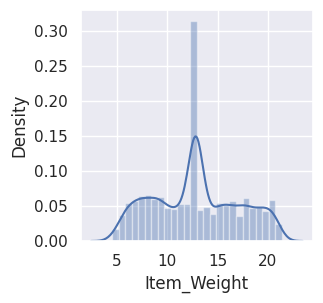

/tmp/ipykernel_681/1665670893.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(big_mart_data['Item_Visibility'])


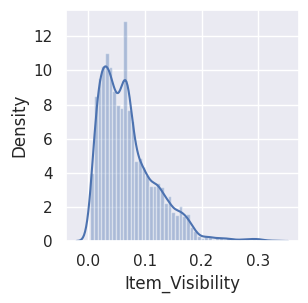

/tmp/ipykernel_681/1665670893.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(big_mart_data['Item_MRP'])


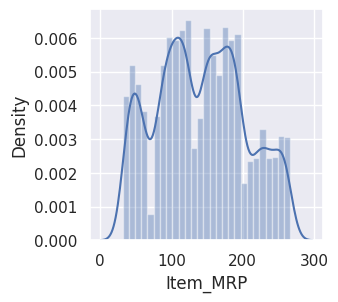

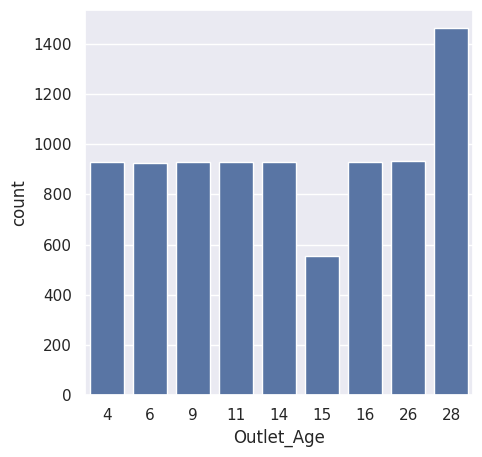

/tmp/ipykernel_681/1665670893.py:15: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(big_mart_data['Item_Outlet_Sales'])


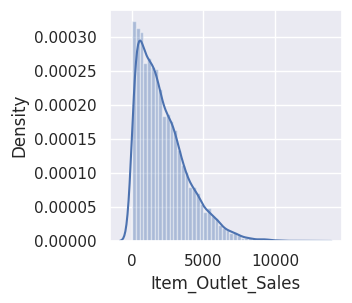

In [21]:
# Item_Weight distribution
plt.figure(figsize=(3,3))
sns.distplot(big_mart_data['Item_Weight'])
plt.show()
plt.figure(figsize=(3,3))
sns.distplot(big_mart_data['Item_Visibility'])
plt.show()
plt.figure(figsize=(3,3))
sns.distplot(big_mart_data['Item_MRP'])
plt.show()
plt.figure(figsize=(5,5))
sns.countplot(x='Outlet_Age', data=big_mart_data)
plt.show()
plt.figure(figsize=(3,3))
sns.distplot(big_mart_data['Item_Outlet_Sales'])
plt.show()

categorical features

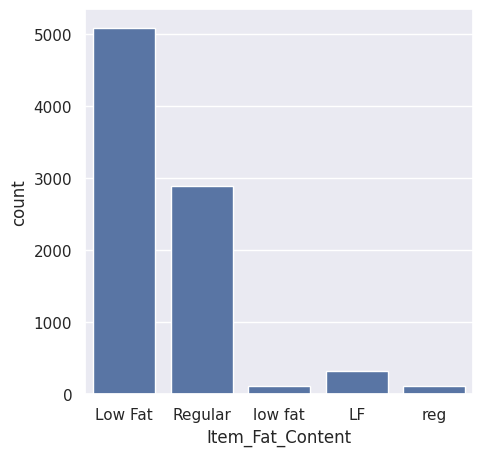

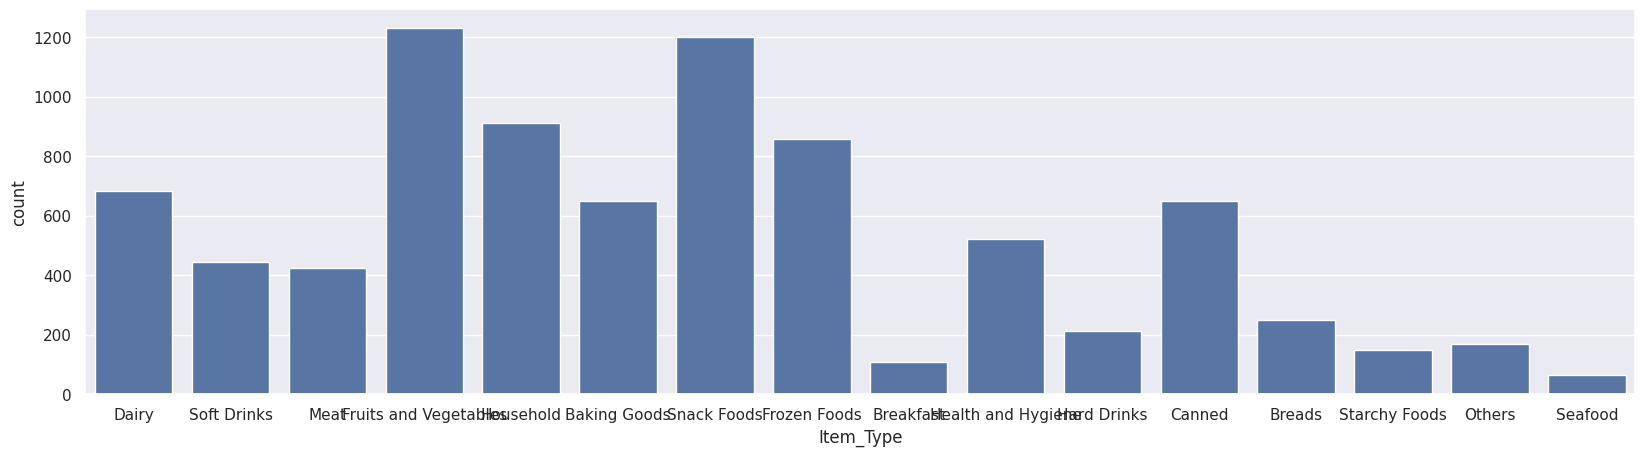

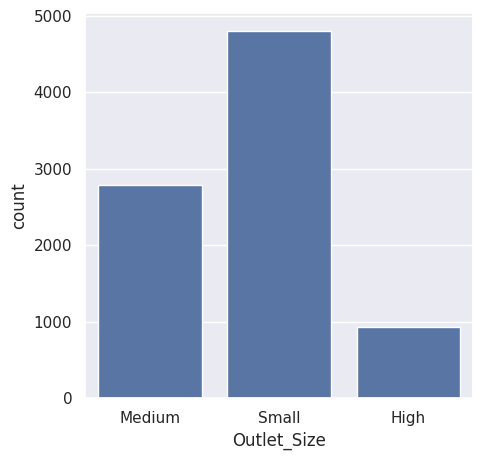

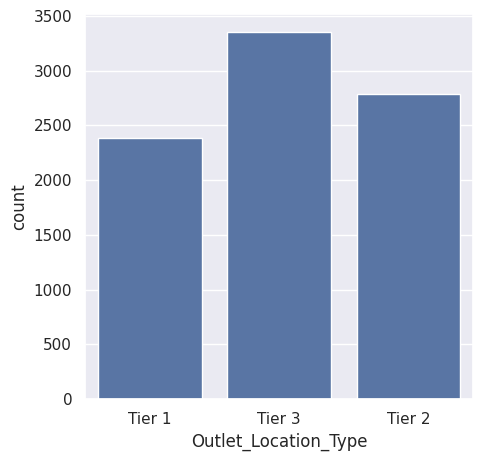

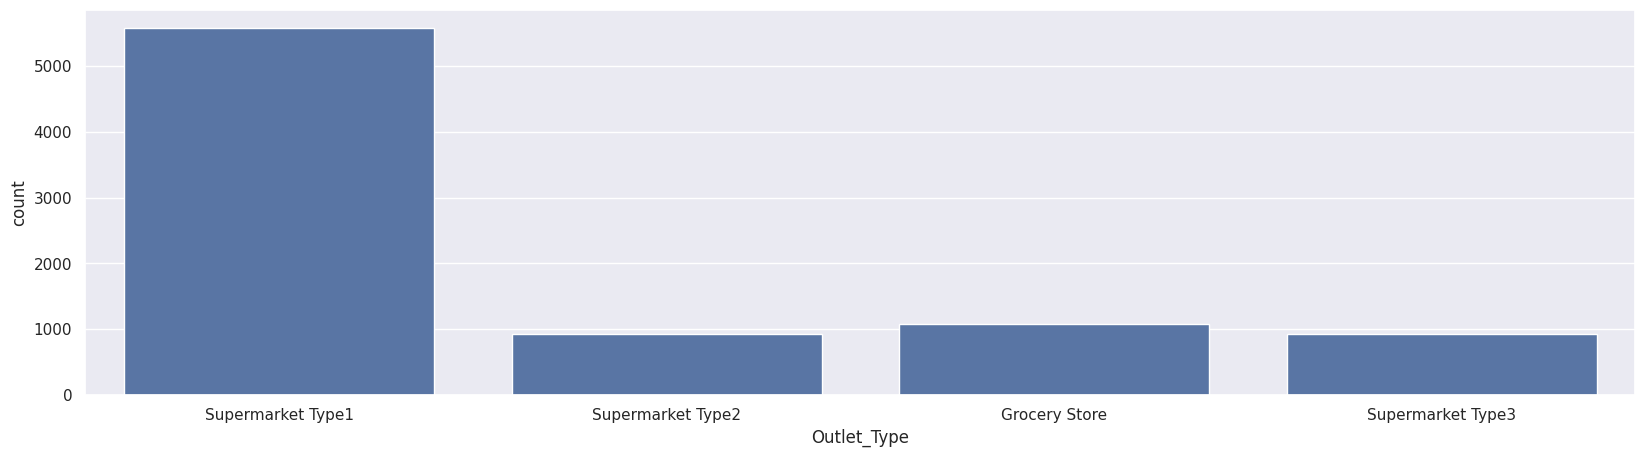

In [22]:
plt.figure(figsize=(5,5))
sns.countplot(x='Item_Fat_Content', data=big_mart_data)
plt.show()
plt.figure(figsize=(20,5))
sns.countplot(x='Item_Type', data=big_mart_data)
plt.show()
plt.figure(figsize=(5,5))
sns.countplot(x='Outlet_Size', data=big_mart_data)
plt.show()
plt.figure(figsize=(5,5))
sns.countplot(x='Outlet_Location_Type', data=big_mart_data)
plt.show()
plt.figure(figsize=(20,5))
sns.countplot(x='Outlet_Type', data=big_mart_data)
plt.show()

data preprocessing

In [23]:
big_mart_data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Outlet_Age
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,Medium,Tier 1,Supermarket Type1,3735.1380,14
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,Medium,Tier 3,Supermarket Type2,443.4228,4
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,Medium,Tier 1,Supermarket Type1,2097.2700,14
3,FDX07,19.20,Regular,0.068513,Fruits and Vegetables,182.0950,OUT010,Small,Tier 3,Grocery Store,732.3800,15
4,NCD19,8.93,Low Fat,0.061322,Household,53.8614,OUT013,High,Tier 3,Supermarket Type1,994.7052,26


In [24]:
big_mart_data['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5089
Regular,2889
LF,316
reg,117
low fat,112


In [25]:
big_mart_data.replace({'LF':'Low Fat', 'reg':'Regular', 'low fat':'Low Fat'}, inplace=True)

In [26]:
big_mart_data['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


In [27]:
encoder = LabelEncoder()

In [28]:
big_mart_data['Item_Identifier'] = encoder.fit_transform(big_mart_data['Item_Identifier'])
big_mart_data['Item_Fat_Content'] = encoder.fit_transform(big_mart_data['Item_Fat_Content'])
big_mart_data['Item_Type'] = encoder.fit_transform(big_mart_data['Item_Type'])
big_mart_data['Outlet_Identifier'] = encoder.fit_transform(big_mart_data['Outlet_Identifier'])
big_mart_data['Outlet_Size'] = big_mart_data['Outlet_Size'].map({'Small': 0, 'Medium': 1, 'High': 2})
big_mart_data['Outlet_Location_Type'] = encoder.fit_transform(big_mart_data['Outlet_Location_Type'])
big_mart_data['Outlet_Type'] = encoder.fit_transform(big_mart_data['Outlet_Type'])

In [29]:
big_mart_data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Outlet_Age
0,156,9.30,0,0.016047,4,249.8092,9,1,0,1,3735.1380,14
1,8,5.92,1,0.019278,14,48.2692,3,1,2,2,443.4228,4
2,662,17.50,0,0.016760,10,141.6180,9,1,0,1,2097.2700,14
3,1121,19.20,1,0.068513,6,182.0950,0,0,2,0,732.3800,15
4,1297,8.93,0,0.061322,9,53.8614,1,2,2,1,994.7052,26


In [30]:
# splitting features and target
X = big_mart_data.drop(columns=['Item_Identifier','Item_Outlet_Sales'], axis=1)
y = big_mart_data['Item_Outlet_Sales']

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [32]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(6818, 10) (1705, 10) (6818,) (1705,)


In [33]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [150, 250, 400],
    'learning_rate': [0.05],
    'max_depth': [3, 4, 5],
    'subsample': [0.8]
}

grid_search = GridSearchCV(
    XGBRegressor(),
    param_grid,
    cv=5,
    scoring='r2',
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 150, 'subsample': 0.8}
Best CV score: 0.601944643759578


In [34]:
best_model = grid_search.best_estimator_

In [35]:
#evaluation
training_data_prediction = best_model.predict(X_train)

In [36]:
testing_data_prediction = best_model.predict(X_test)

In [37]:
# R squared value
r2_train = r2_score(y_train, training_data_prediction)
print(f"R squared value of trainig data : {r2_train}")

R squared value of trainig data : 0.6296523409987731


In [38]:
# R squared value
r2_train = r2_score(y_test, testing_data_prediction)
print(f"R squared value of testing data : {r2_train}")

R squared value of testing data : 0.5895842156060094
